# 04 · Entrenamiento Baseline del Modelo Maestro — 4 niveles de riesgo

Este notebook entrena un **baseline multiclase** usando el dataset maestro integrado de:

- Obra
- Empresa
- Funcionario

La variable objetivo tiene 4 niveles:

| Clase | Descripción |
|---:|---|
| 0 | Sin riesgo |
| 1 | Bajo riesgo |
| 2 | Medio riesgo |
| 3 | Alto/Extremo riesgo |

## Objetivo del notebook

1. Cargar y verificar el dataset maestro.
2. Identificar target y columnas con posible leakage.
3. Preparar variables numéricas y categóricas.
4. Entrenar un baseline con Regresión Logística.
5. Evaluar con métricas multiclase.
6. Guardar modelo, metadata, métricas y gráficos.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

import sklearn
print("scikit-learn:", sklearn.__version__)

scikit-learn: 1.8.0


## 1. Configuración de rutas

La ruta principal se define manualmente para evitar problemas cuando VSCode ejecuta notebooks desde la carpeta `notebooks/`.

In [2]:
BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

DATA_PROC = BASE / "data" / "processed"
MODEL_DIR = BASE / "models" / "production"
REPORTS = BASE / "reports" / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_PROC:", DATA_PROC)
print("MODEL_DIR:", MODEL_DIR)
print("REPORTS:", REPORTS)

BASE: C:\IA_Investigacion\Deteccion_Corrupcion
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed
MODEL_DIR: C:\IA_Investigacion\Deteccion_Corrupcion\models\production
REPORTS: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures


## 2. Buscar y cargar dataset maestro

El notebook busca automáticamente posibles nombres de archivo para el dataset maestro.

In [5]:
candidate_files = [
    "dataset_maestro_v2_4niveles.parquet",
    "dataset_maestro_v2_4niveles_limpio.parquet",
    "dataset_maestro_v1_4niveles.parquet",
    "dataset_maestro_v2_4niveles.parquet",
]

dataset_path = None
for fname in candidate_files:
    p = DATA_PROC / fname
    if p.exists():
        dataset_path = p
        break

if dataset_path is None:
    disponibles = sorted([p.name for p in DATA_PROC.glob("*.parquet")])
    print("Archivos parquet disponibles:")
    for f in disponibles:
        print(" -", f)
    raise FileNotFoundError(
        "No se encontró el dataset maestro. Ajusta candidate_files o dataset_path manualmente."
    )

print("Dataset encontrado:", dataset_path)

df = pd.read_parquet(dataset_path)

print("Shape:", df.shape)
display(df.head())

Dataset encontrado: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_maestro_v2_4niveles.parquet
Shape: (324, 93)


,IDENTIFICADOR_OBRA,obra_PROCESO_mean,obra_PROCESO_max,obra_PROCESO_min,obra_CODIGO_RUC_GANADOR_mean,obra_CODIGO_RUC_GANADOR_max,obra_CODIGO_RUC_GANADOR_min,obra_CONVOCATORIA_PROCESO_GANADO_mean,obra_CONVOCATORIA_PROCESO_GANADO_max,obra_CONVOCATORIA_PROCESO_GANADO_min,...,obra_NUMERO_CONTRATO_nunique,obra_NOMBRE_PARTICIPANTE_first,obra_NOMBRE_PARTICIPANTE_nunique,y_riesgo_obra_4niveles,func_n_registros,func_n_funcionarios,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_pct_riesgo_alto
0,2002060-2434-702592-2064311-19777,3.0,3,3,2.054932e+10,20549322434,20549322434,702592.0,702592,702592,...,1,VERA & MORENO S.A. CONSULTORES DE INGENIERIA(*),6,3,6.0,6.0,3.0,1.166667,1.329160,0.166667
1,2002210-8880-869397-2169938-826,60.0,60,60,2.052240e+10,20522404331,20522404331,869397.0,869397,869397,...,1,consorcio consultor peajes,14,2,12.0,6.0,0.0,0.000000,0.000000,0.000000
2,2002210-8880-870112-2169901-826,60.0,60,60,2.052898e+10,20528975055,20528975055,870112.0,870112,870112,...,1,consorcio consultor peajes,13,2,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,2026767-16256-709096-2067605-143536,14.0,14,14,2.041669e+10,20419183220,20414192531,709096.0,709096,709096,...,1,KUKOVA INGENIEROS S.A.C.(*),10,3,6.0,6.0,3.0,0.500000,1.224745,0.166667
4,2027711-3876-682536-2050524-138320,39.0,39,39,2.055223e+10,20552233787,20552233787,682536.0,682536,682536,...,1,LAGESA INGENIEROS CONSULTORES S.A.,22,3,12.0,11.0,3.0,0.666667,1.230915,0.166667


## 3. Verificación inicial del dataset

Se revisan columnas, duplicados, nulos y posibles columnas objetivo.

In [6]:
print("Columnas:", len(df.columns))
print(df.columns.tolist())

print("\nDuplicados exactos:", df.duplicated().sum())

id_candidates = [c for c in df.columns if "identificador" in c.lower() or c.upper() == "CODIGO_OBRA"]
target_candidates = [
    c for c in df.columns 
    if c.startswith("y_") or "riesgo" in c.lower() or "target" in c.lower()
]

print("\nCandidatas de ID:")
print(id_candidates)

print("\nCandidatas de target/riesgo:")
print(target_candidates)

nulls = (
    df.isna().mean()
      .sort_values(ascending=False)
      .to_frame("pct_nulos")
)
display(nulls.head(20))

Columnas: 93
['IDENTIFICADOR_OBRA', 'obra_PROCESO_mean', 'obra_PROCESO_max', 'obra_PROCESO_min', 'obra_CODIGO_RUC_GANADOR_mean', 'obra_CODIGO_RUC_GANADOR_max', 'obra_CODIGO_RUC_GANADOR_min', 'obra_CONVOCATORIA_PROCESO_GANADO_mean', 'obra_CONVOCATORIA_PROCESO_GANADO_max', 'obra_CONVOCATORIA_PROCESO_GANADO_min', 'obra_TotalProcesosParticipantes_mean', 'obra_TotalProcesosParticipantes_max', 'obra_TotalProcesosParticipantes_min', 'obra_CODIGO_CONTRATO_mean', 'obra_CODIGO_CONTRATO_max', 'obra_CODIGO_CONTRATO_min', 'obra_CODIGO_RUC_PARTICIPANTE_mean', 'obra_CODIGO_RUC_PARTICIPANTE_max', 'obra_CODIGO_RUC_PARTICIPANTE_min', 'obra_n_ofertas_mean', 'obra_n_ofertas_max', 'obra_n_ofertas_min', 'obra_monto_ofertado_min_mean', 'obra_monto_ofertado_min_max', 'obra_monto_ofertado_min_min', 'obra_monto_ofertado_max_mean', 'obra_monto_ofertado_max_max', 'obra_monto_ofertado_max_min', 'obra_monto_ofertado_mean_mean', 'obra_monto_ofertado_mean_max', 'obra_monto_ofertado_mean_min', 'obra_monto_ofertado_med

,pct_nulos
obra_monto_ofertado_std_max,0.222222
obra_monto_ofertado_std_min,0.222222
obra_monto_ofertado_std_mean,0.222222
obra_obra_2b_n_registros_mean,0.206790
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_min,0.206790
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_min,0.206790
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_max,0.206790
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_mean,0.206790
obra_obra_2b_n_registros_max,0.206790
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_max,0.206790


## 4. Definir target

Se intenta detectar automáticamente el target principal. Si el nombre en tu dataset es distinto, ajusta la variable `TARGET`.

In [7]:
preferred_targets = [
    "y_riesgo_obra_4niveles",
    "y_riesgo_maestro_4niveles",
    "y_riesgo_4niveles",
    "y_riesgo_nivel_4",
    "y_riesgo_nivel",
]

TARGET = None
for t in preferred_targets:
    if t in df.columns:
        TARGET = t
        break

if TARGET is None:
    candidates = [c for c in df.columns if c.startswith("y_")]
    if candidates:
        TARGET = candidates[0]

if TARGET is None:
    raise KeyError(
        "No se detectó target automáticamente. Define TARGET manualmente."
    )

print("TARGET seleccionado:", TARGET)

df[TARGET] = df[TARGET].astype(int)

print("\nDistribución del target:")
target_dist = df[TARGET].value_counts().sort_index()
display(target_dist.to_frame("cantidad"))

print("\nDistribución porcentual:")
display((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2).to_frame("porcentaje"))

TARGET seleccionado: y_riesgo_obra_4niveles

Distribución del target:


,cantidad
y_riesgo_obra_4niveles,
0,31
1,52
2,87
3,154



Distribución porcentual:


,porcentaje
y_riesgo_obra_4niveles,
0,9.57
1,16.05
2,26.85
3,47.53


## 5. Limpieza y control de leakage

Se eliminan columnas que podrían contener directamente la respuesta o información posterior usada para construir el target.

La regla práctica es:

> Si la columna contiene el riesgo observado o una etiqueta derivada del riesgo, no debe entrar como predictor.

In [8]:
# Columnas que siempre deben excluirse
explicit_exclude = [
    TARGET,
    "RIESGO_OBRA",
    "RIESGO_DESCRIPCION_OBRA",
    "riesgo_obra",
    "riesgo_descripcion_obra",
    "y_riesgo_binario",
    "y_riesgo_alto",
    "y_riesgo_nivel",
    "y_riesgo_obra_5niveles",
    "y_riesgo_empresa",
    "y_riesgo_funcionario",
    "target",
]

# Excluir también cualquier columna y_ distinta al target
auto_exclude = [
    c for c in df.columns
    if c.startswith("y_") and c != TARGET
]

# Excluir textos de descripción de riesgo, si existen
risk_text_cols = [
    c for c in df.columns
    if "riesgo_descripcion" in c.lower()
    or "descripcion_riesgo" in c.lower()
]

cols_exclude = sorted(set(explicit_exclude + auto_exclude + risk_text_cols))
cols_exclude_existing = [c for c in cols_exclude if c in df.columns]

print("Columnas excluidas por leakage/target:")
for c in cols_exclude_existing:
    print(" -", c)

X = df.drop(columns=cols_exclude_existing, errors="ignore")
y = df[TARGET].astype(int)

print("\nX inicial:", X.shape)
print("y:", y.shape)

Columnas excluidas por leakage/target:
 - y_riesgo_obra_4niveles

X inicial: (324, 92)
y: (324,)


## 6. Limpieza adicional de columnas

Se eliminan columnas 100% nulas, columnas constantes y columnas tipo identificador de muy alta cardinalidad que pueden generar ruido.

In [9]:
# Eliminar columnas 100% nulas
all_null_cols = [c for c in X.columns if X[c].isna().all()]
print("Columnas 100% nulas:", len(all_null_cols))
if all_null_cols:
    print(all_null_cols)
    X = X.drop(columns=all_null_cols)

# Eliminar columnas constantes
constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
print("\nColumnas constantes:", len(constant_cols))
if constant_cols:
    print(constant_cols)
    X = X.drop(columns=constant_cols)

# Identificadores que normalmente no deben actuar como predictores
id_like_cols = [
    c for c in X.columns
    if c.upper() in [
        "IDENTIFICADOR_OBRA",
        "CODIGO_OBRA",
        "CODIGO_UNICO",
        "CODIGO_RUC",
        "CODIGO_DNI",
        "DNI",
        "RUC",
    ]
]

print("\nColumnas ID-like encontradas:")
print(id_like_cols)

# Guardamos grupos/ids antes de excluirlos
GROUP_COL = None
for c in ["IDENTIFICADOR_OBRA", "CODIGO_OBRA", "CODIGO_UNICO"]:
    if c in df.columns:
        GROUP_COL = c
        break

print("GROUP_COL:", GROUP_COL)

# Para el baseline maestro a nivel obra, excluimos IDs del modelo
X = X.drop(columns=id_like_cols, errors="ignore")

print("\nX después de limpieza:", X.shape)

Columnas 100% nulas: 0

Columnas constantes: 9
['obra_CODIGO_UNICO_nunique', 'obra_SECTOR_nunique', 'obra_DEPARTAMENTO_nunique', 'obra_NIVEL_GOBIERNO_nunique', 'obra_OBJETO_PROCESO_nunique', 'obra_CODIGO_OBRA_nunique', 'obra_NOMBREOBRA_nunique', 'obra_METODO_CONTRATACION_nunique', 'obra_NUMERO_CONTRATO_nunique']

Columnas ID-like encontradas:
['IDENTIFICADOR_OBRA']
GROUP_COL: IDENTIFICADOR_OBRA

X después de limpieza: (324, 82)


## 7. Tipos de variables y preprocesamiento

Las variables numéricas reciben imputación por mediana.  
Las categóricas reciben imputación por moda y `OneHotEncoder`.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_cols = X.select_dtypes(include=["number", "int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Variables numéricas:", len(num_cols))
print("Variables categóricas:", len(cat_cols))

display(pd.DataFrame({
    "tipo": ["numéricas", "categóricas"],
    "cantidad": [len(num_cols), len(cat_cols)]
}))

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

Variables numéricas: 71
Variables categóricas: 11


,tipo,cantidad
0,numéricas,71
1,categóricas,11


## 8. Split de entrenamiento y prueba

Como el dataset maestro está a nivel de obra, se usa `train_test_split` estratificado.

Si el dataset tuviera varias filas por obra, debería usarse `GroupShuffleSplit`.

In [11]:
from sklearn.model_selection import train_test_split

min_class_count = y.value_counts().min()
print("Mínimo de registros por clase:", min_class_count)

if min_class_count < 2:
    raise ValueError(
        "Alguna clase tiene menos de 2 registros. No se puede hacer split estratificado confiable."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribución train:")
display(y_train.value_counts().sort_index().to_frame("train"))

print("\nDistribución test:")
display(y_test.value_counts().sort_index().to_frame("test"))

Mínimo de registros por clase: 31
X_train: (259, 82)
X_test: (65, 82)

Distribución train:


,train
y_riesgo_obra_4niveles,
0,25
1,42
2,69
3,123



Distribución test:


,test
y_riesgo_obra_4niveles,
0,6
1,10
2,18
3,31


## 9. Baseline multiclase: Regresión Logística

Se usa `class_weight="balanced"` para compensar desbalance de clases.

Nota: en versiones recientes de scikit-learn puede no aceptarse `multi_class`, por eso no se usa ese argumento.

In [12]:
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42
    ))
])

clf.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 10. Evaluación del baseline

Métricas principales:

- Accuracy
- Balanced Accuracy
- Macro F1
- Weighted F1

Para este problema, **Macro F1** y **Balanced Accuracy** son más importantes que Accuracy.

In [13]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

y_pred = clf.predict(X_test)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
    "weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
}

print("Métricas:")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

labels = sorted(y.unique().tolist())
class_names = {
    0: "Sin riesgo",
    1: "Bajo riesgo",
    2: "Medio riesgo",
    3: "Alto/Extremo riesgo",
}

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=[class_names.get(i, str(i)) for i in labels],
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nMatriz de confusión:")
print(cm)

Métricas:
{
  "accuracy": 0.2923076923076923,
  "balanced_accuracy": 0.23315412186379927,
  "macro_f1": 0.2261467086834734,
  "weighted_f1": 0.31369855634561516
}

Classification report:
                     precision    recall  f1-score   support

         Sin riesgo       0.00      0.00      0.00         6
        Bajo riesgo       0.14      0.30      0.19        10
       Medio riesgo       0.29      0.28      0.29        18
Alto/Extremo riesgo       0.55      0.35      0.43        31

           accuracy                           0.29        65
          macro avg       0.25      0.23      0.23        65
       weighted avg       0.36      0.29      0.31        65


Matriz de confusión:
[[ 0  4  2  0]
 [ 2  3  4  1]
 [ 2  3  5  8]
 [ 2 12  6 11]]


## 11. Gráfico de matriz de confusión

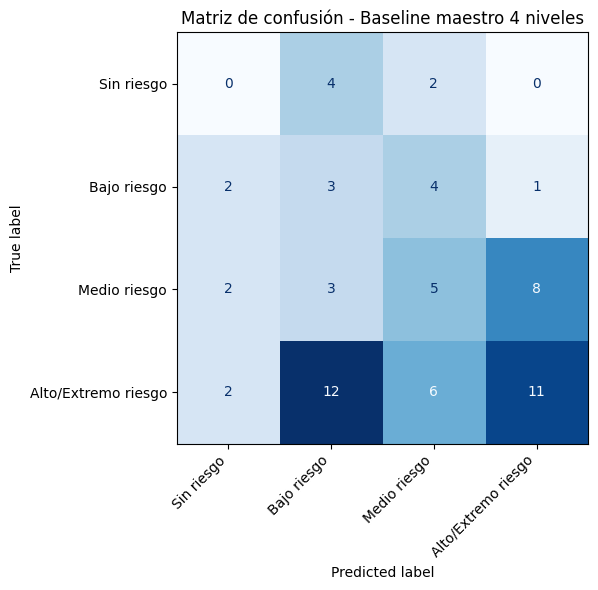

Gráfico guardado en: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures\confusion_matrix_baseline_maestro_4niveles.png


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

if plt is not None:
    display_labels = [class_names.get(i, str(i)) for i in labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    ax.set_title("Matriz de confusión - Baseline maestro 4 niveles")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    cm_path = REPORTS / "confusion_matrix_baseline_maestro_4niveles.png"
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Gráfico guardado en:", cm_path)
else:
    print("matplotlib no está disponible.")

## 12. Probabilidades por clase

La regresión logística permite obtener probabilidades por clase mediante `predict_proba`.

In [15]:
if hasattr(clf, "predict_proba"):
    proba = clf.predict_proba(X_test)
    proba_df = pd.DataFrame(
        proba,
        columns=[f"proba_clase_{c}" for c in clf.named_steps["model"].classes_]
    )
    proba_df["y_real"] = y_test.reset_index(drop=True)
    proba_df["y_pred"] = y_pred

    display(proba_df.head())

    proba_out = DATA_PROC / "baseline_maestro_4niveles_predicciones_test.csv"
    proba_df.to_csv(proba_out, index=False, encoding="utf-8-sig")
    print("Predicciones test guardadas en:", proba_out)
else:
    print("El modelo no soporta predict_proba.")

,proba_clase_0,proba_clase_1,proba_clase_2,proba_clase_3,y_real,y_pred
0,0.293401,0.205008,0.209494,0.292097,2,0
1,0.185557,0.265121,0.271347,0.277976,2,3
2,0.173250,0.261459,0.121526,0.443765,2,3
3,0.034713,0.048490,0.282529,0.634268,3,3
4,0.266375,0.295308,0.217385,0.220932,0,1


Predicciones test guardadas en: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\baseline_maestro_4niveles_predicciones_test.csv


## 13. Guardar modelo, metadata y métricas

Se guardan salidas en:

- `models/production/pipeline_maestro_4niveles_baseline.pkl`
- `models/production/pipeline_maestro_4niveles_baseline_meta.json`
- `data/processed/baseline_maestro_4niveles_metrics.json`

In [16]:
MODEL_PATH = MODEL_DIR / "pipeline_maestro_4niveles_baseline.pkl"
META_PATH = MODEL_DIR / "pipeline_maestro_4niveles_baseline_meta.json"
METRICS_PATH = DATA_PROC / "baseline_maestro_4niveles_metrics.json"

joblib.dump(clf, MODEL_PATH)

meta = {
    "model_name": "pipeline_maestro_4niveles_baseline",
    "model_type": "LogisticRegression",
    "solver": "lbfgs",
    "class_weight": "balanced",
    "target": TARGET,
    "dataset_path": str(dataset_path),
    "n_rows": int(df.shape[0]),
    "n_columns_original": int(df.shape[1]),
    "n_features_model": int(X.shape[1]),
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "excluded_columns": cols_exclude_existing + all_null_cols + constant_cols + id_like_cols,
    "classes": {str(k): v for k, v in class_names.items()},
    "labels_present": [int(v) for v in labels],
    "metrics": metrics,
    "random_state": 42,
    "test_size": 0.2,
    "sklearn_version": sklearn.__version__,
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Modelo guardado en:", MODEL_PATH)
print("Metadata guardada en:", META_PATH)
print("Métricas guardadas en:", METRICS_PATH)

Modelo guardado en: C:\IA_Investigacion\Deteccion_Corrupcion\models\production\pipeline_maestro_4niveles_baseline.pkl
Metadata guardada en: C:\IA_Investigacion\Deteccion_Corrupcion\models\production\pipeline_maestro_4niveles_baseline_meta.json
Métricas guardadas en: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\baseline_maestro_4niveles_metrics.json


## 14. Prueba rápida de inferencia

Se prueba cargar el modelo guardado y predecir sobre algunas filas.

In [17]:
loaded = joblib.load(MODEL_PATH)

sample = X.head(5)
sample_pred = loaded.predict(sample)

if hasattr(loaded, "predict_proba"):
    sample_proba = loaded.predict_proba(sample)
    display(pd.DataFrame(sample_proba, columns=[f"proba_clase_{c}" for c in loaded.named_steps["model"].classes_]))

print("Predicción de muestra:", sample_pred)

,proba_clase_0,proba_clase_1,proba_clase_2,proba_clase_3
0,0.033390,0.073217,0.289596,0.603797
1,0.293401,0.205008,0.209494,0.292097
2,0.288672,0.213814,0.209374,0.288141
3,0.032815,0.088978,0.294367,0.583841
4,0.235584,0.257659,0.258349,0.248408


Predicción de muestra: [3 0 0 3 2]


## 15. Conclusiones

> Se entrenó un baseline multiclase de cuatro niveles de riesgo sobre el dataset maestro integrado. El modelo utiliza variables de obra, empresa y funcionario, excluyendo columnas que podrían generar leakage. Se aplicó regresión logística con ponderación de clases y se evaluó con balanced accuracy, macro F1, weighted F1 y matriz de confusión. Este resultado constituye una línea base inicial para comparar posteriormente modelos más robustos como Random Forest, XGBoost o LightGBM.